## Conditional Graph

In [16]:
from typing import TypedDict

from anyio.functools import initial_missing
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [17]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalNumber: int

In [18]:
def adder(state:AgentState)->AgentState:
    """this node add two numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

In [19]:
def subtractor(state:AgentState)->AgentState:
    """this node subtracts two numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

In [20]:
def decide_next_node(state:AgentState)->AgentState:
    """This node decides next node of the graph"""
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"


In [21]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("sub_node", subtractor)
graph.add_node("router", lambda
    state: state)  ## passthrough function ---we are not changing anything from this function so passthrough

graph.add_edge(START, "router")
graph.add_conditional_edges(
                            "router",
                            decide_next_node,
                            {
                                "addition_operation": "add_node",
                                "subtraction_operation": "sub_node"
                            }
                            )
graph.add_edge("add_node", END)
graph.add_edge("sub_node", END)

app = graph.compile()

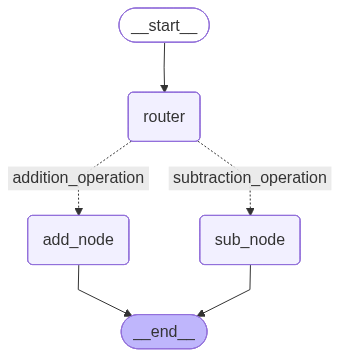

In [22]:
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
initial_state_1 = AgentState(number1=10, number2=2, operation="-")
app.invoke(initial_state_1)

{'number1': 10, 'number2': 2, 'operation': '-', 'finalNumber': 8}